In [35]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully 🚀")

Libraries loaded successfully 🚀


In [36]:
np.random.seed(42)


In [37]:
# Create date range (2 years of data)
dates = pd.date_range(start="2022-01-01", end="2023-12-31")

# Create stores and items
stores = [101, 102, 103]
items = [1001, 1002, 1003, 1004]

print("Dates:", len(dates))
print("Stores:", stores)
print("Items:", items)

Dates: 730
Stores: [101, 102, 103]
Items: [1001, 1002, 1003, 1004]


In [38]:
data = []

for store in stores:
    for item in items:
        base_demand = np.random.randint(20, 50)
        
        for date in dates:
            # Seasonality (weekends higher demand)
            if date.dayofweek >= 5:
                demand = base_demand + np.random.randint(5, 15)
            else:
                demand = base_demand + np.random.randint(-5, 5)
            
            # Promotion effect
            on_promo = np.random.choice([0, 1], p=[0.8, 0.2])
            if on_promo == 1:
                demand += np.random.randint(10, 20)
            
            # Stockout simulation
            stockout_flag = np.random.choice([0, 1], p=[0.9, 0.1])
            if stockout_flag == 1:
                demand = max(0, demand - np.random.randint(10, 20))
            
            # Price variation
            price = np.random.uniform(50, 200)
            
            data.append([
                date, store, item, demand, price, on_promo, stockout_flag
            ])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    "date", "store_id", "item_id", "qty_sold", "price", "on_promo", "stockout_flag"
])

print("Dataset created successfully ✅")

Dataset created successfully ✅


In [39]:
df.head()


,date,store_id,item_id,qty_sold,price,on_promo,stockout_flag
0,2022-01-01,101,1001,51,73.402796,1,0
1,2022-01-02,101,1001,33,100.056292,0,0
2,2022-01-03,101,1001,28,195.486478,0,0
3,2022-01-04,101,1001,16,95.636336,0,1
4,2022-01-05,101,1001,26,128.716199,0,0


In [40]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           8760 non-null   datetime64[ns]
 1   store_id       8760 non-null   int64         
 2   item_id        8760 non-null   int64         
 3   qty_sold       8760 non-null   int64         
 4   price          8760 non-null   float64       
 5   on_promo       8760 non-null   int64         
 6   stockout_flag  8760 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(5)
memory usage: 479.2 KB


In [41]:
df.to_csv("retail_data.csv", index=False)
print("Dataset saved as retail_data.csv 📁")


Dataset saved as retail_data.csv 📁


In [42]:
import pandas as pd

df = pd.read_csv("retail_data.csv", parse_dates=["date"])

print("Dataset loaded successfully ✅")
df.head()

Dataset loaded successfully ✅


,date,store_id,item_id,qty_sold,price,on_promo,stockout_flag
0,2022-01-01,101,1001,51,73.402796,1,0
1,2022-01-02,101,1001,33,100.056292,0,0
2,2022-01-03,101,1001,28,195.486478,0,0
3,2022-01-04,101,1001,16,95.636336,0,1
4,2022-01-05,101,1001,26,128.716199,0,0


In [43]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)

Shape of dataset: (8760, 7)

Columns:
 Index(['date', 'store_id', 'item_id', 'qty_sold', 'price', 'on_promo',
       'stockout_flag'],
      dtype='object')


In [44]:
df.isnull().sum()

date             0
store_id         0
item_id          0
qty_sold         0
price            0
on_promo         0
stockout_flag    0
dtype: int64

In [45]:
df = df.drop_duplicates()
print("Duplicates removed ✅")


Duplicates removed ✅


In [46]:
print("Negative values in qty_sold:", (df["qty_sold"] < 0).sum())

Negative values in qty_sold: 0


In [47]:
df = df[df["stockout_flag"] == 0]
print("Stockout rows removed ✅")

Stockout rows removed ✅


In [48]:
df = df.sort_values(by=["store_id", "item_id", "date"])
print("Data sorted ✅")

Data sorted ✅


In [49]:
df = df.reset_index(drop=True)

In [50]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7947 entries, 0 to 7946
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           7947 non-null   datetime64[ns]
 1   store_id       7947 non-null   int64         
 2   item_id        7947 non-null   int64         
 3   qty_sold       7947 non-null   int64         
 4   price          7947 non-null   float64       
 5   on_promo       7947 non-null   int64         
 6   stockout_flag  7947 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(5)
memory usage: 434.7 KB


,date,store_id,item_id,qty_sold,price,on_promo,stockout_flag
0,2022-01-01,101,1001,51,73.402796,1,0
1,2022-01-02,101,1001,33,100.056292,0,0
2,2022-01-03,101,1001,28,195.486478,0,0
3,2022-01-05,101,1001,26,128.716199,0,0
4,2022-01-07,101,1001,24,141.131728,0,0


In [51]:
df.to_csv("clean_retail_data.csv", index=False)
print("Clean dataset saved ✅")

Clean dataset saved ✅


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
print("Visualization libraries loaded ✅")

Visualization libraries loaded ✅


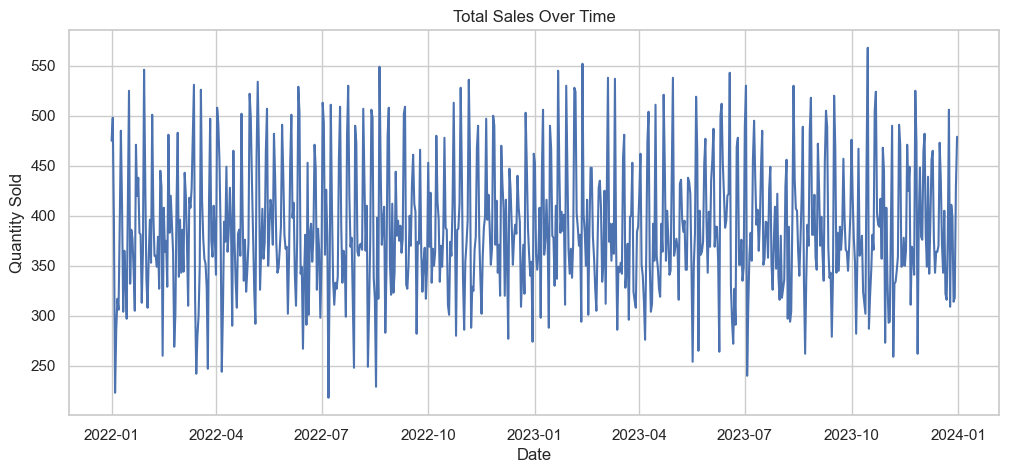

In [53]:
daily_sales = df.groupby("date")["qty_sold"].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.show()

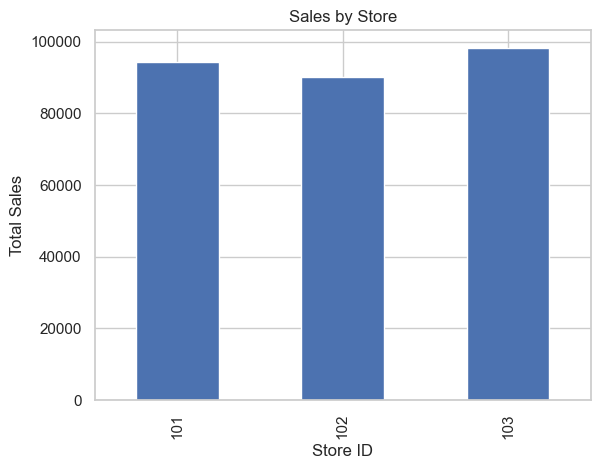

In [54]:
store_sales = df.groupby("store_id")["qty_sold"].sum()

store_sales.plot(kind="bar")
plt.title("Sales by Store")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")
plt.show()

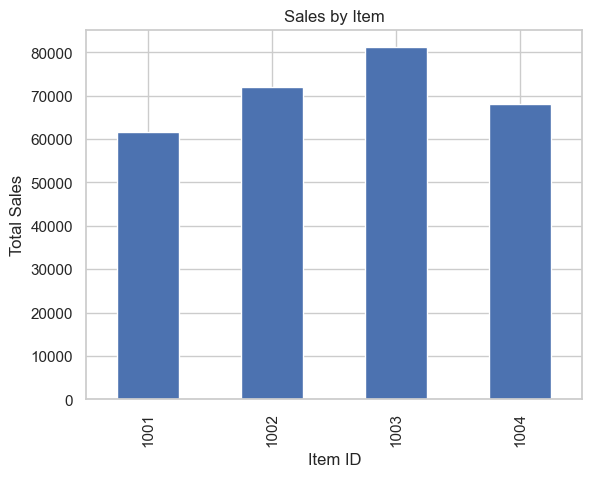

In [55]:
item_sales = df.groupby("item_id")["qty_sold"].sum()

item_sales.plot(kind="bar")
plt.title("Sales by Item")
plt.xlabel("Item ID")
plt.ylabel("Total Sales")
plt.show()

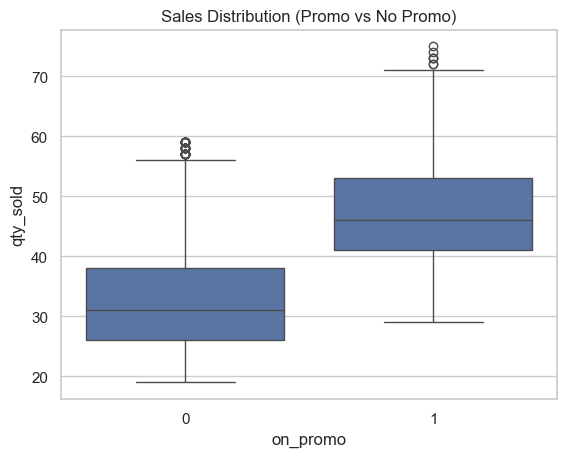

In [56]:
sns.boxplot(x="on_promo", y="qty_sold", data=df)

plt.title("Sales Distribution (Promo vs No Promo)")
plt.show()

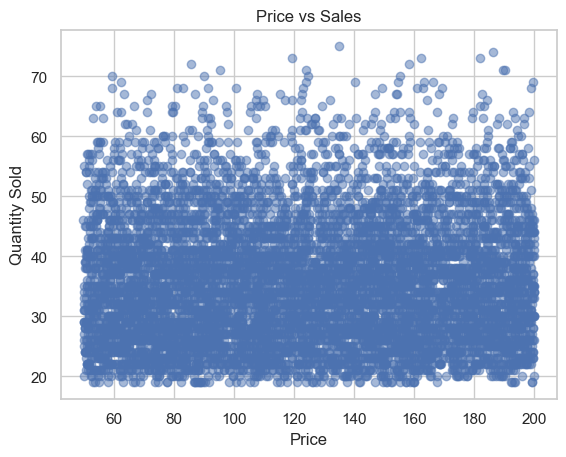

In [57]:
plt.scatter(df["price"], df["qty_sold"], alpha=0.5)

plt.title("Price vs Sales")
plt.xlabel("Price")
plt.ylabel("Quantity Sold")
plt.show()

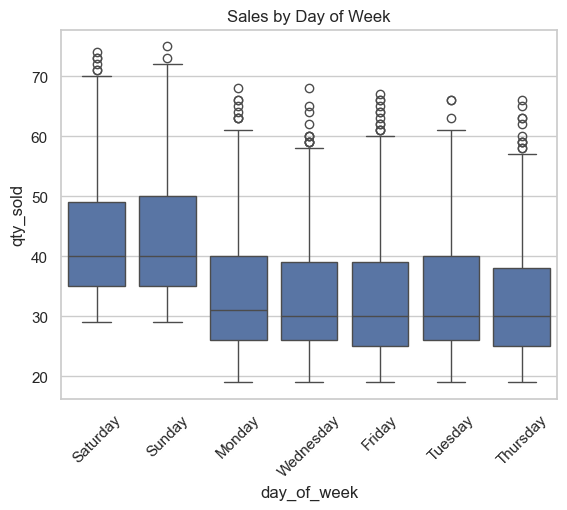

In [58]:
df["day_of_week"] = df["date"].dt.day_name()

sns.boxplot(x="day_of_week", y="qty_sold", data=df)

plt.title("Sales by Day of Week")
plt.xticks(rotation=45)
plt.show()

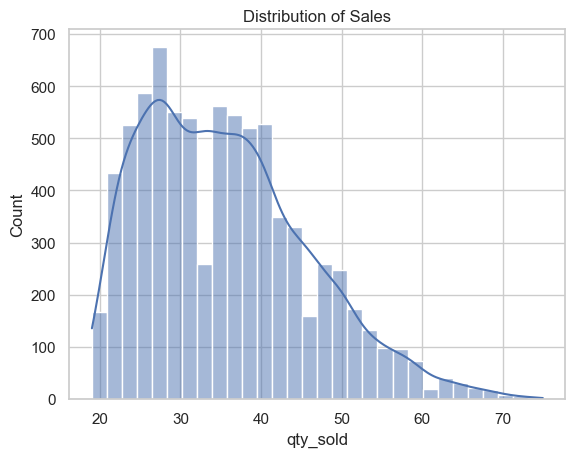

In [59]:
sns.histplot(df["qty_sold"], bins=30, kde=True)

plt.title("Distribution of Sales")
plt.show()

In [60]:
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["day_of_week"] = df["date"].dt.dayofweek

print("Date features created ✅")
df.head()

Date features created ✅


,date,store_id,item_id,qty_sold,price,on_promo,stockout_flag,day_of_week,day,month,year
0,2022-01-01,101,1001,51,73.402796,1,0,5,1,1,2022
1,2022-01-02,101,1001,33,100.056292,0,0,6,2,1,2022
2,2022-01-03,101,1001,28,195.486478,0,0,0,3,1,2022
3,2022-01-05,101,1001,26,128.716199,0,0,2,5,1,2022
4,2022-01-07,101,1001,24,141.131728,0,0,4,7,1,2022


In [61]:
df["lag_1"] = df.groupby(["store_id", "item_id"])["qty_sold"].shift(1)
df["lag_7"] = df.groupby(["store_id", "item_id"])["qty_sold"].shift(7)

print("Lag features created ✅")

Lag features created ✅


In [62]:
df["rolling_mean_7"] = df.groupby(["store_id", "item_id"])["qty_sold"].transform(lambda x: x.rolling(7).mean())
df["rolling_mean_14"] = df.groupby(["store_id", "item_id"])["qty_sold"].transform(lambda x: x.rolling(14).mean())

print("Rolling features created ✅")

Rolling features created ✅


In [63]:
df = df.dropna()
print("Null values removed ✅")

Null values removed ✅


In [64]:
df.head()

,date,store_id,item_id,qty_sold,price,on_promo,stockout_flag,day_of_week,day,month,year,lag_1,lag_7,rolling_mean_7,rolling_mean_14
13,2022-01-17,101,1001,46,94.023226,1,0,0,17,1,2022,58.0,32.0,34.428571,33.571429
14,2022-01-18,101,1001,23,165.690552,0,0,1,18,1,2022,46.0,27.0,33.857143,31.571429
15,2022-01-19,101,1001,44,179.465514,1,0,2,19,1,2022,23.0,21.0,37.142857,32.357143
16,2022-01-20,101,1001,28,105.622738,0,0,3,20,1,2022,44.0,26.0,37.428571,32.357143
17,2022-01-21,101,1001,28,91.208269,0,0,4,21,1,2022,28.0,28.0,37.428571,32.500000


In [65]:
df.to_csv("final_retail_data.csv", index=False)
print("Final dataset saved ✅")

Final dataset saved ✅


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("ML libraries loaded ✅")

ML libraries loaded ✅


In [68]:
features = [
    "store_id", "item_id", "price", "on_promo",
    "day", "month", "year", "day_of_week",
    "lag_1", "lag_7", "rolling_mean_7", "rolling_mean_14"
]

target = "qty_sold"

X = df[features]
y = df[target]

print("Features and target selected ✅")

Features and target selected ✅


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split into train and test ✅")

Data split into train and test ✅


In [71]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully 🚀")

Model trained successfully 🚀


In [72]:
y_pred = model.predict(X_test)

print("Prediction done ✅")

Prediction done ✅


In [73]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2.7730981398332264
RMSE: 3.326413756554458


In [74]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
0,46,44.77
1,43,41.07
2,27,25.31
3,27,23.29
4,28,25.99


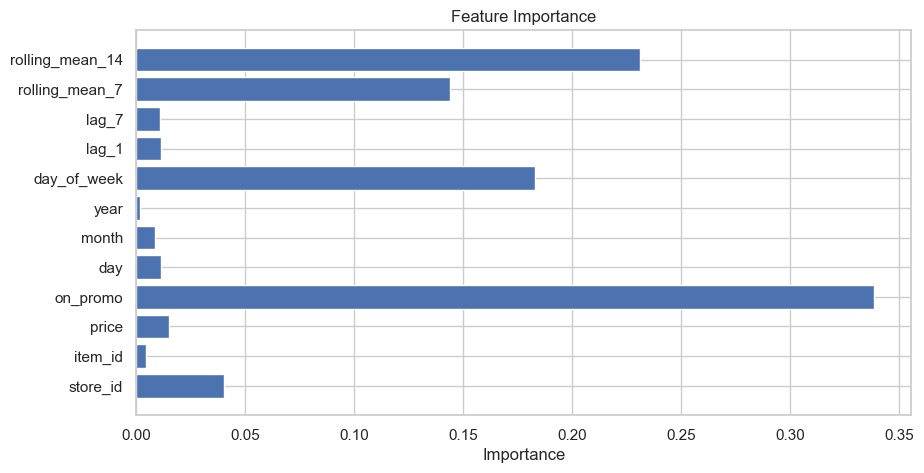

In [75]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(10,5))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [76]:
import joblib

joblib.dump(model, "demand_forecasting_model.pkl")

print("Model saved successfully ✅")

Model saved successfully ✅
